# Predicción de abandono de clientes

Este cuaderno sirve como punto de partida para explorar el dataset de Telco Customer Churn y preparar el flujo de trabajo de modelado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / 'data' / 'raw'
print('Directorio del proyecto:', PROJECT_ROOT)
print('Archivos en data/raw:')
for path in DATA_PATH.glob('*'):
    print(path.name)


Directorio del proyecto: C:\Users\maydd\mi-cv-node\customer-churn-prediction\notebooks
Archivos en data/raw:


In [2]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().resolve().parent))
from src.download_dataset import download_telco_dataset

raw_dir = download_telco_dataset()
print('Dataset listo en:', raw_dir)


Descargando dataset desde Kaggle...
Archivo guardado en: C:\Users\maydd\mi-cv-node\customer-churn-prediction\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset listo en: C:\Users\maydd\mi-cv-node\customer-churn-prediction\data\raw


In [3]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))
from src.preprocess import load_and_preprocess

raw_path = PROJECT_ROOT / 'data' / 'raw' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(raw_path)
print('Shape del dataset:', df.shape)
print('Columnas:', df.columns.tolist())
print('Tipos de datos:')
print(df.dtypes)
print('Valores faltantes:')
print(df.isna().sum())


Shape del dataset: (7043, 21)
Columnas: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Tipos de datos:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
Valores faltantes:

In [4]:
processed_df = load_and_preprocess(raw_path, PROJECT_ROOT / 'data' / 'processed' / 'telco_customer_churn_processed.csv')
print(processed_df.head())
print('Shape procesado:', processed_df.shape)


Dataset limpio guardado en: C:\Users\maydd\mi-cv-node\customer-churn-prediction\data\processed\telco_customer_churn_processed.csv
Shape final: (7043, 31)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet 

Gráfico guardado en: C:\Users\maydd\mi-cv-node\customer-churn-prediction\images\eda_churn.png


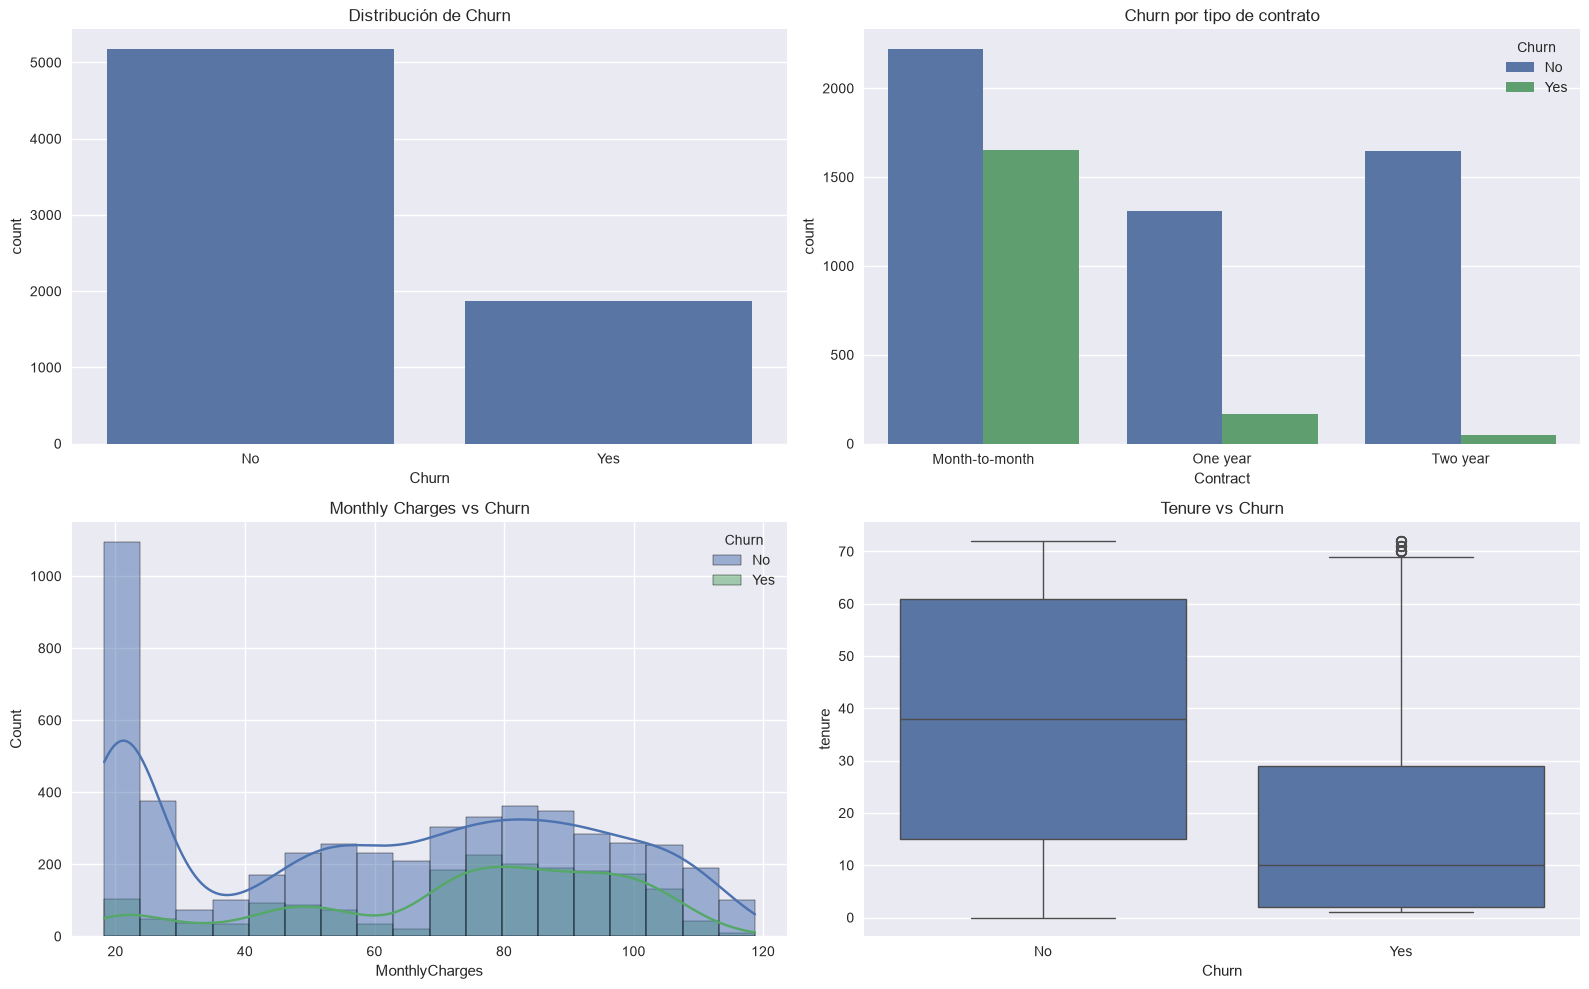

In [5]:
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=df, x='Churn', ax=axes[0, 0])
axes[0, 0].set_title('Distribución de Churn')

sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0, 1])
axes[0, 1].set_title('Churn por tipo de contrato')

sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Monthly Charges vs Churn')

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1, 1])
axes[1, 1].set_title('Tenure vs Churn')

plt.tight_layout()
out_path = PROJECT_ROOT / 'images' / 'eda_churn.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print('Gráfico guardado en:', out_path)
plt.show()
